# ============================================================
# NYC Yellow Taxi Analytics — NB2: EDA & Visualisation
# Sahil Changotra | April 2026
# ============================================================

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns',None)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Set consistent plot style
sns.set_theme(style='whitegrid',palette='muted')
plt.rcParams['figure.dpi'] = 150
plt.rcParams['font.size'] = 11


In [3]:
# ── Load clean data ────────────────────────────────────────
df = pd.read_csv('../data/clean/nyc_taxi_clean.csv',
                 parse_dates=['tpep_pickup_datetime', 'tpep_dropoff_datetime'])

# ── Fix columns that lose dtype after CSV save/load ────────
df['pickup_day_of_week'] = df['tpep_pickup_datetime'].dt.day_name()
df['is_weekend'] = df['pickup_day_of_week'].isin(['Saturday', 'Sunday'])
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_month'] = df['tpep_pickup_datetime'].dt.month

print(f"✅ Clean data loaded: {df.shape}")
print(f"Weekend trips: {df['is_weekend'].sum():,} ({df['is_weekend'].mean()*100:.1f}%)")

✅ Clean data loaded: (18176765, 28)
Weekend trips: 4,874,988 (26.8%)


### Section 1 - Descriptive Statistics

In [4]:
df.head()

,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,airport_fee,trip_duration_mins,pickup_hour,pickup_day_of_week,pickup_month,pickup_month_name,is_weekend,speed_mph,tip_pct,payment_type_label
0,2,2023-06-30 23:59:59,2023-07-01 00:47:49,2,17.62,2,N,132,230,1,70.00,0.00,0.50,0.00,6.55,1.00,82.30,2.50,1.75,47.83,23,Friday,6,June,False,0.01,0.00,Credit Card
1,2,2023-06-30 23:59:57,2023-07-01 00:17:36,1,3.32,1,N,255,198,1,18.40,1.00,0.50,2.50,0.00,1.00,23.40,0.00,0.00,17.65,23,Friday,6,June,False,0.00,13.59,Credit Card
2,1,2023-06-30 23:59:55,2023-07-01 00:14:20,1,2.80,1,N,231,107,1,14.90,3.50,0.50,3.95,0.00,1.00,23.85,2.50,0.00,14.42,23,Friday,6,June,False,0.00,26.51,Credit Card
3,2,2023-06-30 23:59:55,2023-07-01 00:05:52,1,0.89,1,N,237,163,1,7.20,1.00,0.50,2.00,0.00,1.00,14.20,2.50,0.00,5.95,23,Friday,6,June,False,0.00,27.78,Credit Card
4,2,2023-06-30 23:59:55,2023-07-01 00:07:08,4,1.56,1,N,211,90,1,10.00,1.00,0.50,3.00,0.00,1.00,18.00,2.50,0.00,7.22,23,Friday,6,June,False,0.00,30.00,Credit Card


In [5]:
key_cols = ['fare_amount','trip_distance','trip_duration_mins','tip_amount','tip_pct','total_amount','speed_mph','passenger_count']
stats = df[key_cols].describe().T
stats['median'] = df[key_cols].median()
stats['skewness'] = df[key_cols].skew()
stats['kurtosis'] = df[key_cols].kurt()

print("====DESCRIPTIVE STATISTICS====")
print(stats[['count','mean','median','std','min','25%','75%','max','skewness']].round(2))

====DESCRIPTIVE STATISTICS====
                         count  mean  median   std  min   25%   75%    max  \
fare_amount        18176765.00 19.04   13.50 16.05 0.01  9.30 21.20  73.00   
trip_distance      18176765.00  3.46    1.81  4.32 0.01  1.10  3.42  20.25   
trip_duration_mins 18176765.00 15.85   12.28 12.60 1.02  7.58 19.80 179.77   
tip_amount         18176765.00  3.55    2.86  3.96 0.00  1.00  4.40 984.30   
tip_pct            18176765.00 20.48   24.19 13.75 0.00  9.20 29.30 100.00   
total_amount       18176765.00 28.13   20.70 20.69 1.01 15.95 30.00 102.66   
speed_mph          18176765.00  0.00    0.00  0.00 0.00  0.00  0.00   0.33   
passenger_count    18176765.00  1.39    1.00  0.88 1.00  1.00  1.00   9.00   

                    skewness  
fare_amount             2.02  
trip_distance           2.42  
trip_duration_mins      2.27  
tip_amount              5.95  
tip_pct                 0.08  
total_amount            2.09  
speed_mph              13.20  
passenger_count   

### SECTION 2 — DISTRIBUTION ANALYSIS


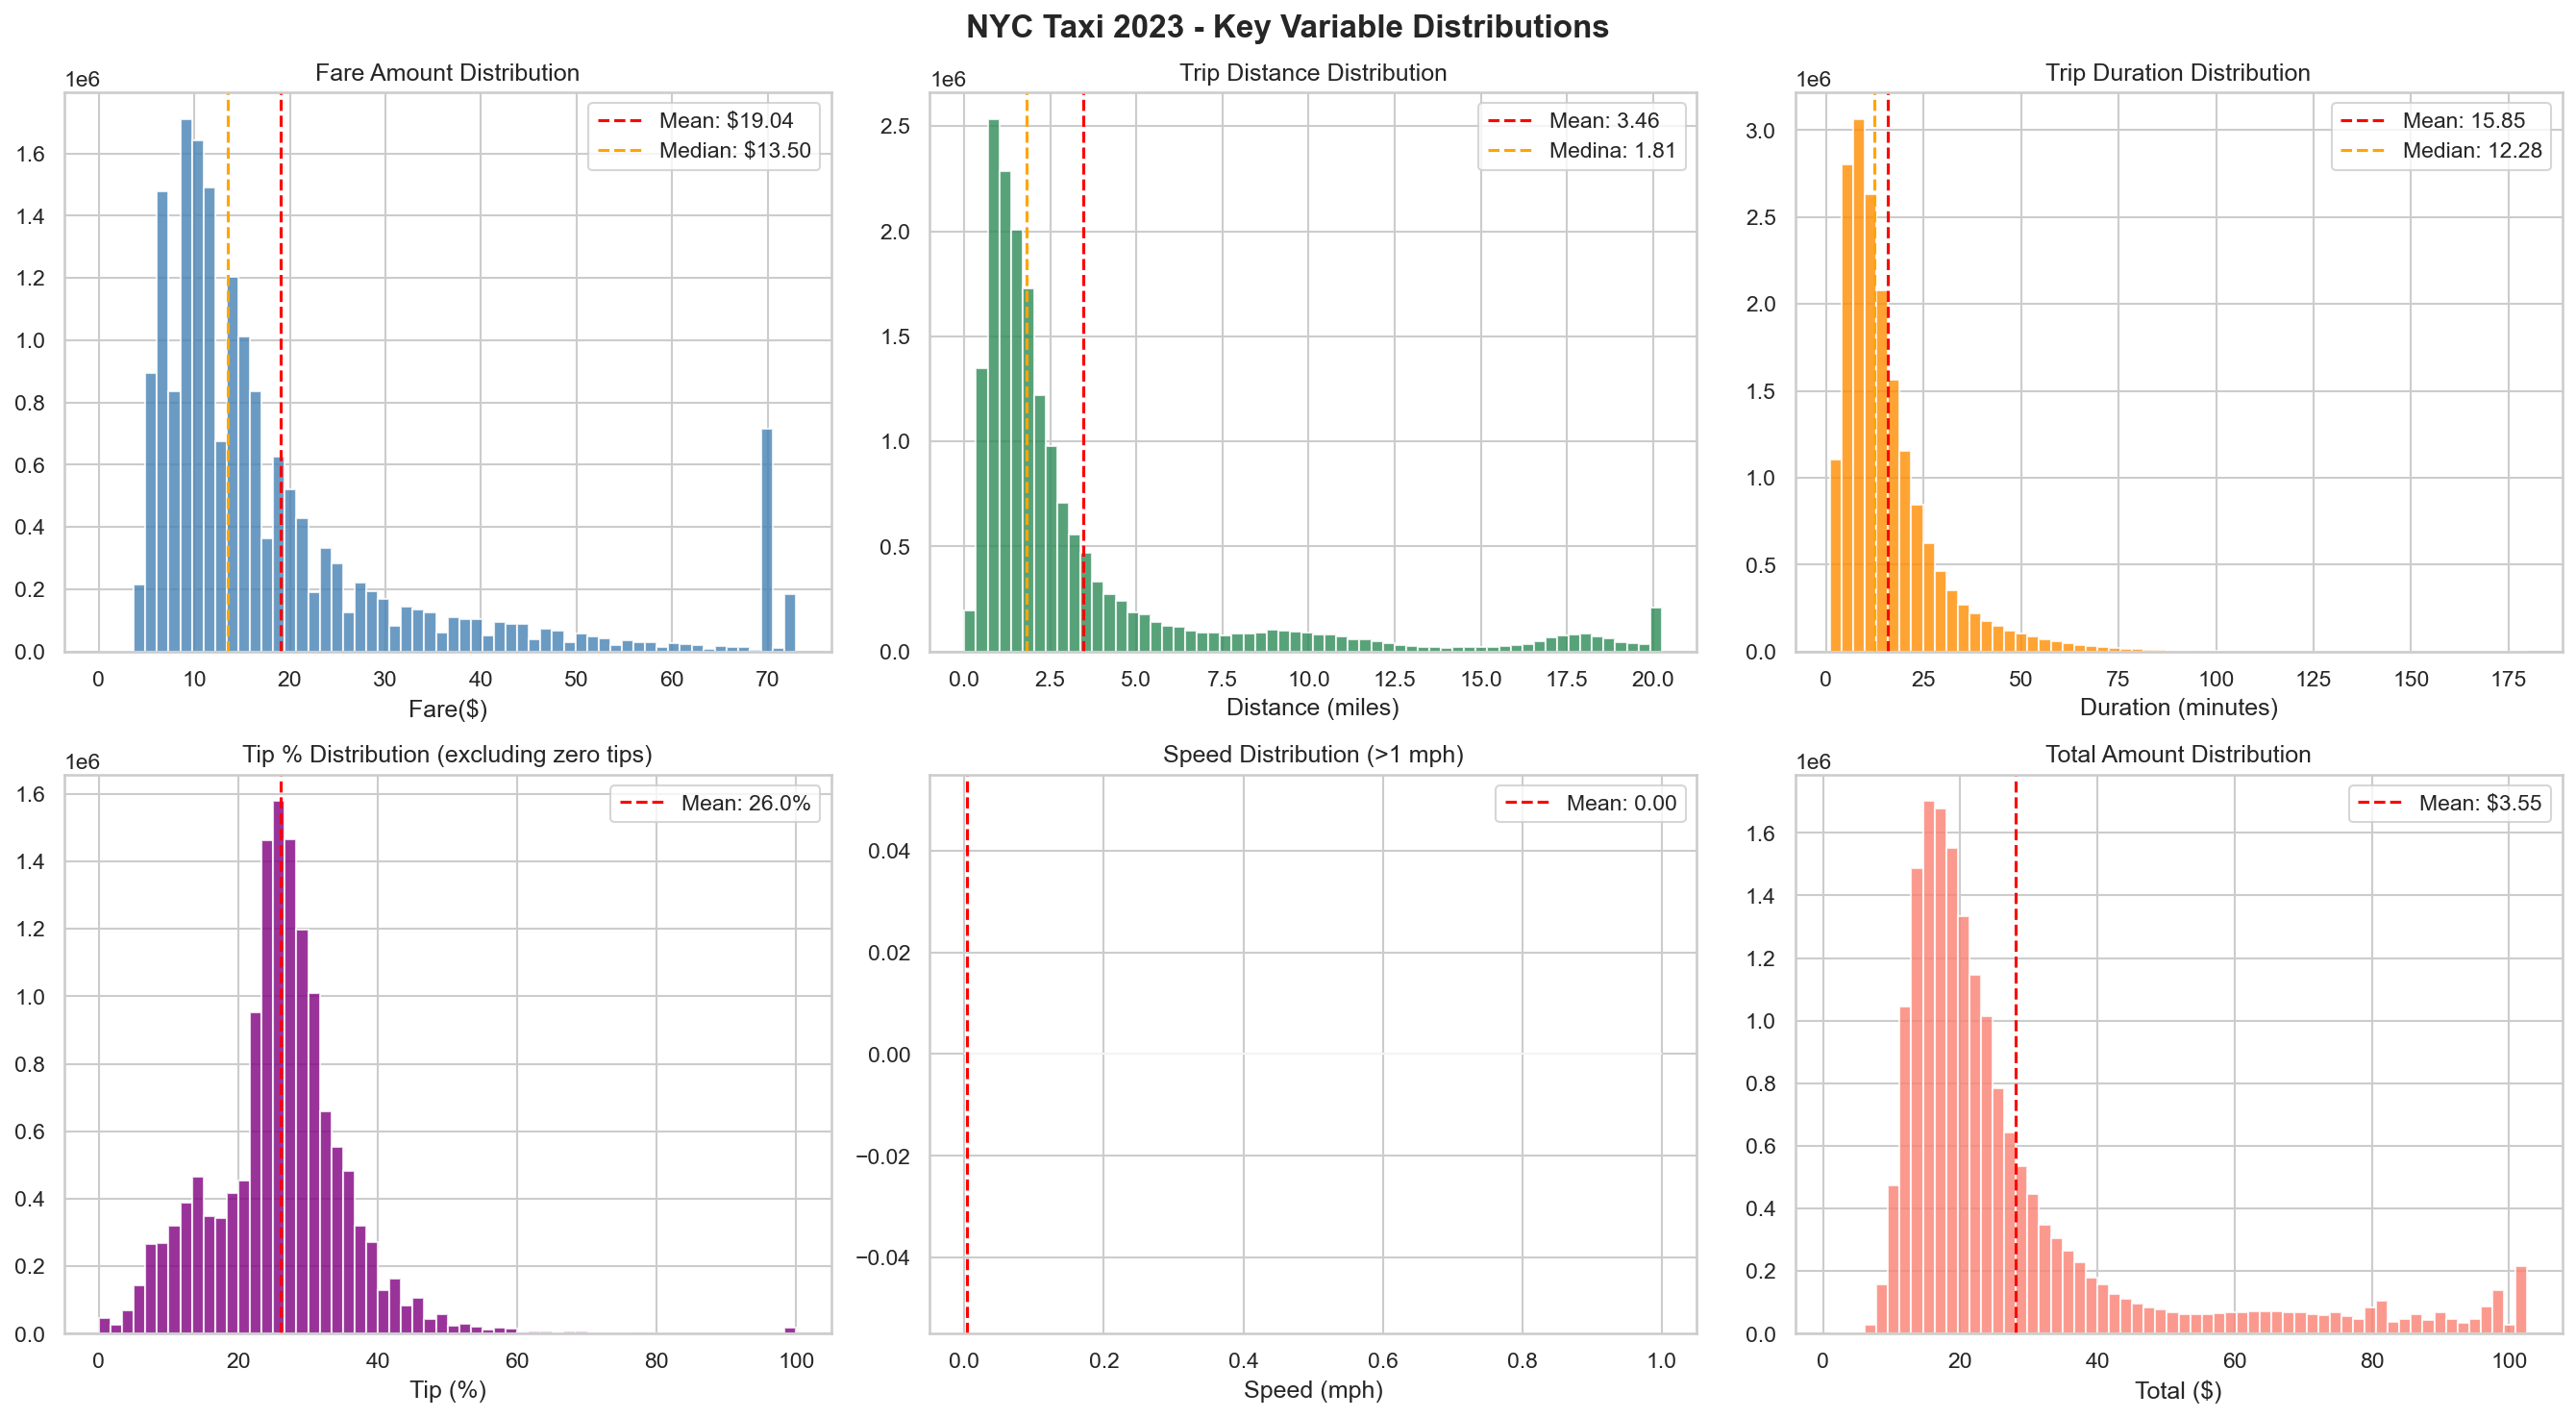

Distribution plots saved


In [6]:
fig, axes = plt.subplots(2, 3, figsize = (18,10))
fig.suptitle('NYC Taxi 2023 - Key Variable Distributions', fontsize = 16, fontweight = 'bold')

# Fare amount
axes[0,0].hist(df['fare_amount'],bins=60,color='steelblue',edgecolor='white',alpha=0.8)
axes[0,0].axvline(df['fare_amount'].mean(),color='red',linestyle='--',label=f"Mean: ${df['fare_amount'].mean():.2f}")
axes[0,0].axvline(df['fare_amount'].median(),color='orange',linestyle='--',label=f"Median: ${df['fare_amount'].median():.2f}")
axes[0,0].set_title('Fare Amount Distribution')
axes[0,0].set_xlabel('Fare($)')
axes[0,0].legend()

# Trip distance
axes[0,1].hist(df['trip_distance'],bins=60,color='seagreen',edgecolor='white',alpha=0.8)
axes[0,1].axvline(df['trip_distance'].mean(), color = 'red',linestyle='--',label=f"Mean: {df['trip_distance'].mean():.2f}")
axes[0,1].axvline(df['trip_distance'].median(),color = 'orange',linestyle='--',label=f"Medina: {df['trip_distance'].median():.2f}")
axes[0,1].set_title('Trip Distance Distribution')
axes[0,1].set_xlabel('Distance (miles)')
axes[0,1].legend()

# Trip duration
axes[0,2].hist(df['trip_duration_mins'],bins=60, color = 'darkorange',edgecolor='white',alpha=0.8)
axes[0,2].axvline(df['trip_duration_mins'].mean(),color='red',linestyle='--',label=f"Mean: {df['trip_duration_mins'].mean():.2f}")
axes[0,2].axvline(df['trip_duration_mins'].median(),color='orange',linestyle='--',label=f"Median: {df['trip_duration_mins'].median():.2f}")
axes[0,2].set_title('Trip Duration Distribution')
axes[0,2].set_xlabel('Duration (minutes)')
axes[0,2].legend()

# Tip Percentage
axes[1,0].hist(df[df['tip_pct']>0]['tip_pct'],bins=60, color='purple',edgecolor='white',alpha=0.8)
axes[1,0].axvline(df[df['tip_pct']>0]['tip_pct'].mean(),color='red',linestyle='--',
            label=f"Mean: {df[df['tip_pct']>0]['tip_pct'].mean():.1f}%")
axes[1,0].set_title('Tip % Distribution (excluding zero tips)')
axes[1,0].set_xlabel('Tip (%)')
axes[1,0].legend()

# Speed
axes[1,1].hist(df[df['speed_mph']>1]['speed_mph'],bins=60, color='teal',edgecolor='white', alpha=0.8)
axes[1,1].axvline(df['speed_mph'].mean(),color='red',linestyle='--',label=f"Mean: {df['speed_mph'].mean():.2f}")
axes[1,1].set_title('Speed Distribution (>1 mph)')
axes[1,1].set_xlabel('Speed (mph)')
axes[1,1].legend()

# Total Amount
axes[1,2].hist(df['total_amount'], bins=60, color='salmon',edgecolor='white',alpha=0.8)
axes[1,2].axvline(df['total_amount'].mean(), color='red',linestyle='--',label=f"Mean: ${df['tip_amount'].mean():.2f}")
axes[1,2].set_title('Total Amount Distribution')
axes[1,2].set_xlabel('Total ($)')
axes[1,2].legend()

plt.tight_layout()
plt.savefig('../outputs/nb2_distributions.png', dpi=150,bbox_inches='tight')
plt.show()
print("Distribution plots saved")

### Time Pattern Analysis

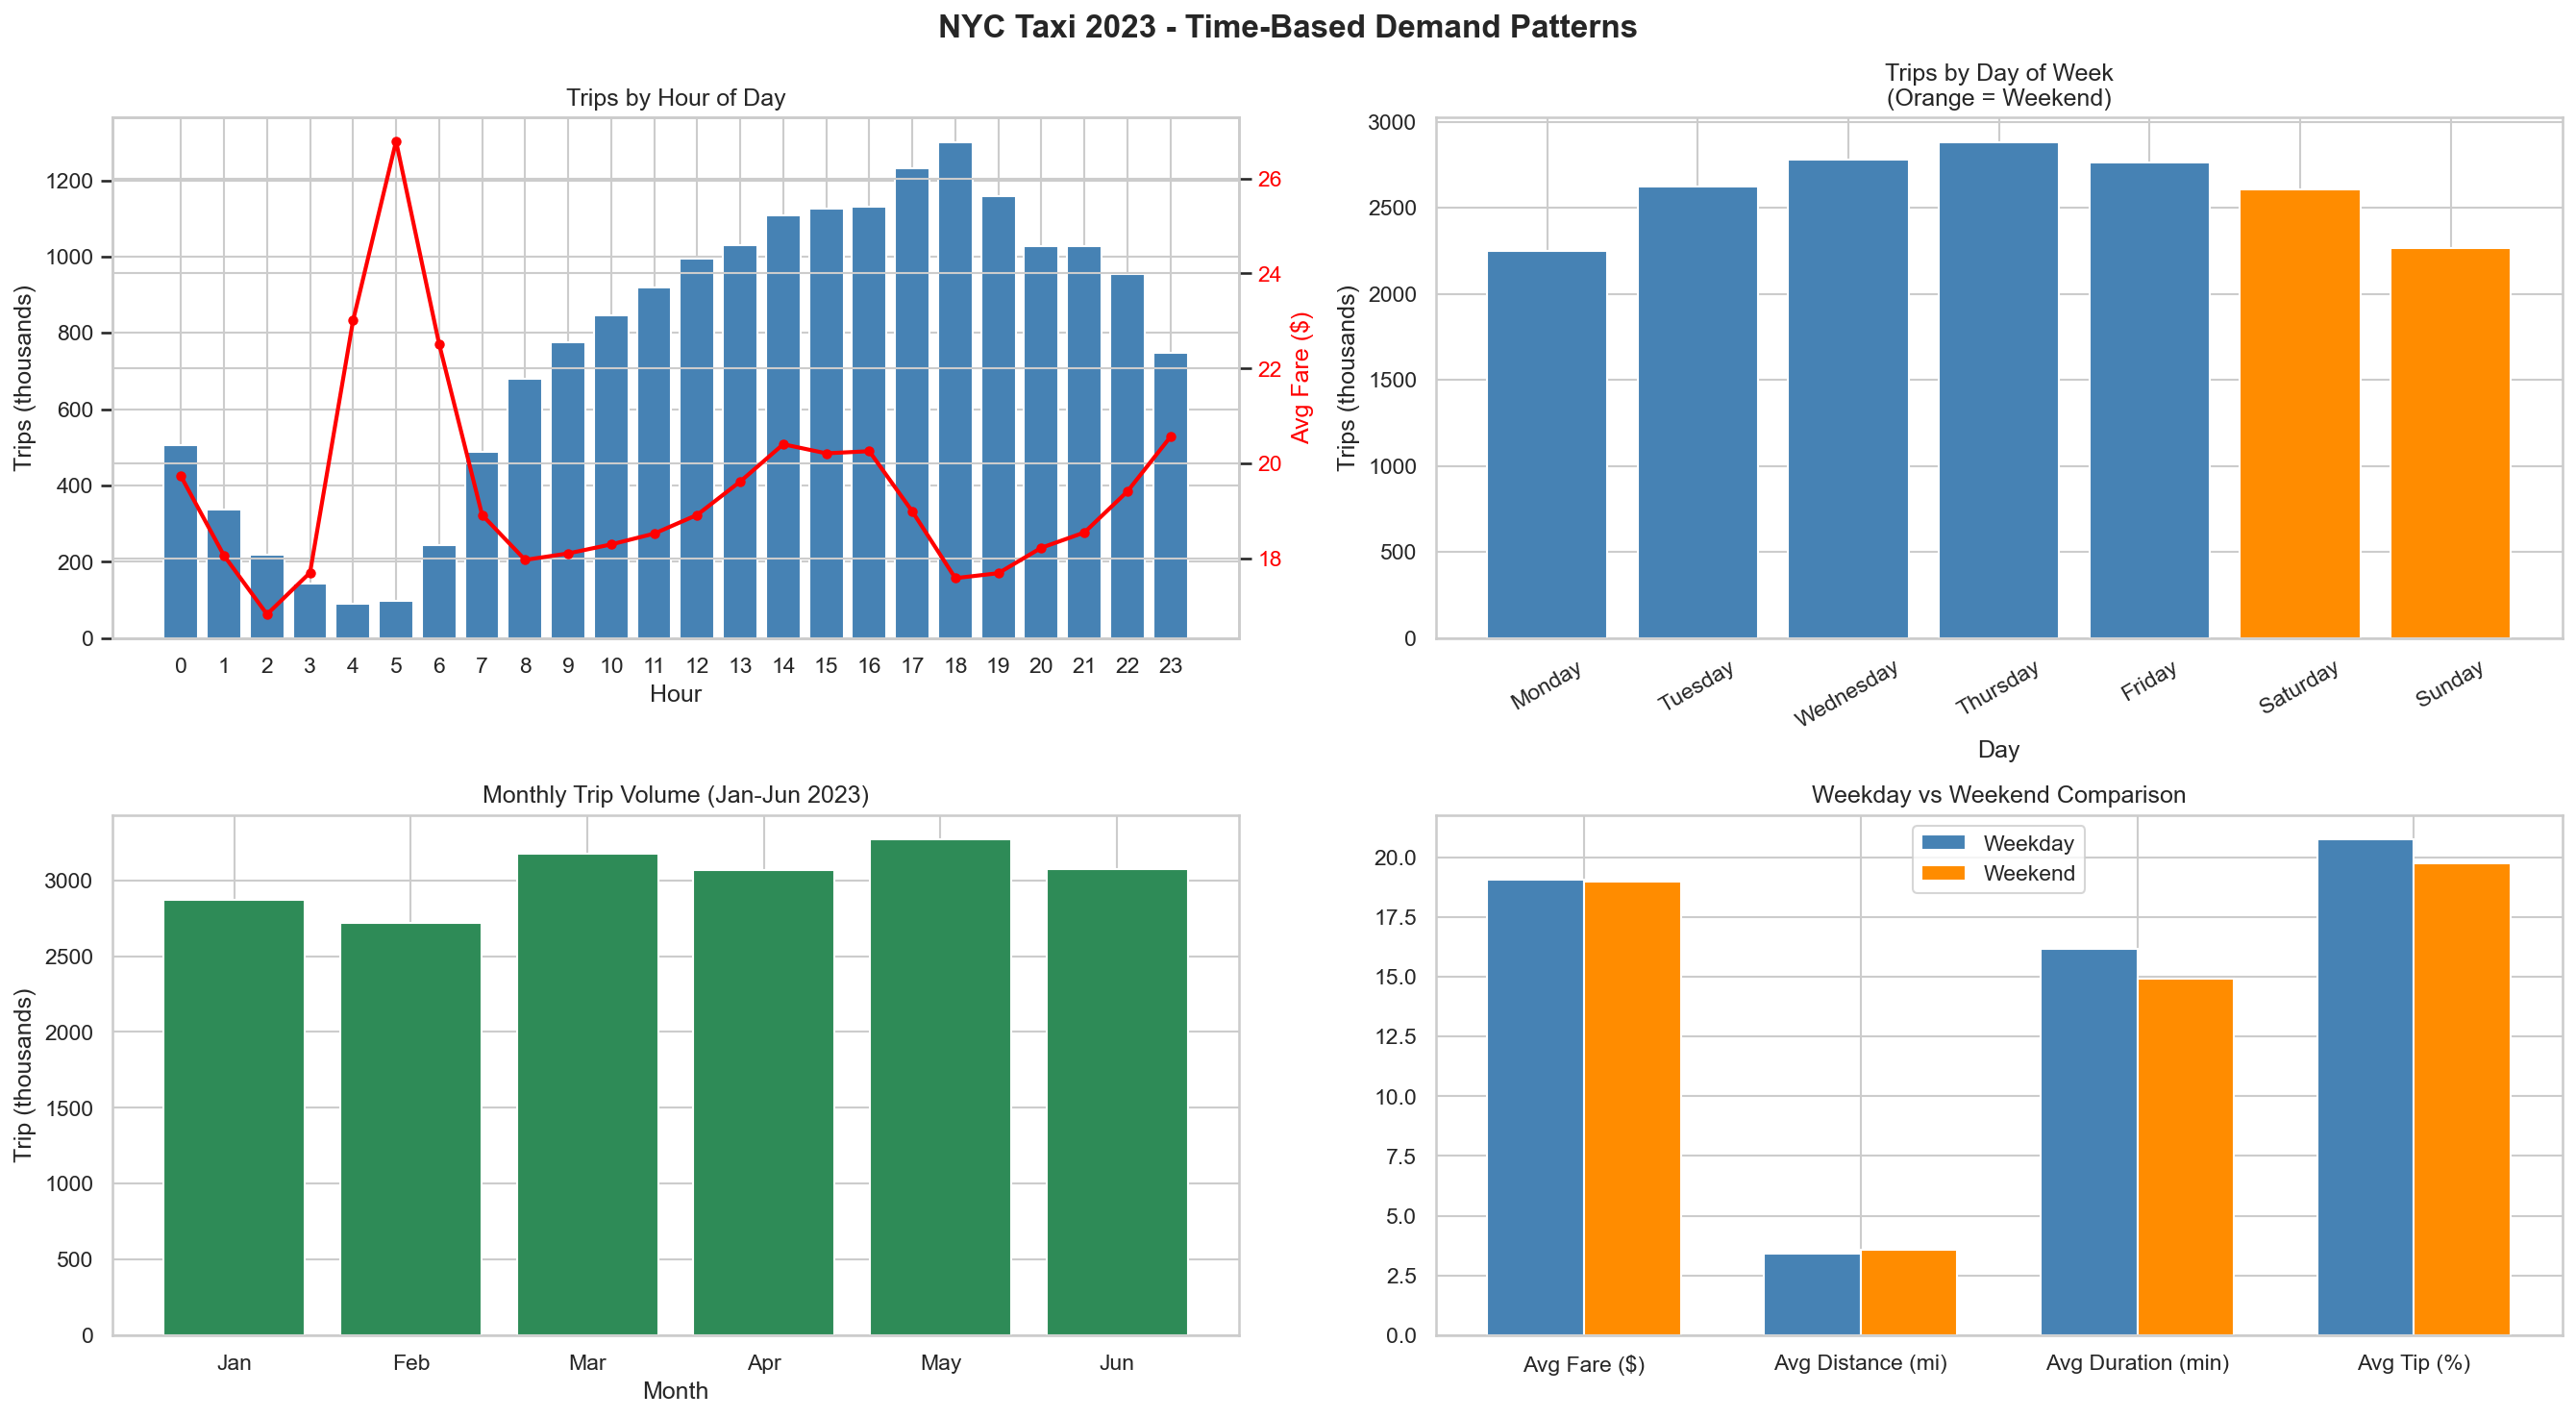

Time patter plots saved


In [7]:
fig, axes = plt.subplots(2,2, figsize=(18,10))
fig.suptitle('NYC Taxi 2023 - Time-Based Demand Patterns', fontsize=16, fontweight='bold')

# Hourly demand
hourly = df.groupby('pickup_hour').agg(
    trips = ('fare_amount','count'),
    avg_fare = ('fare_amount','mean')
).reset_index()

ax1 = axes[0,0]
bars = ax1.bar(hourly['pickup_hour'],hourly['trips']/1000, color = 'steelblue',edgecolor='white')
ax1.set_title('Trips by Hour of Day')
ax1.set_xlabel('Hour')
ax1.set_ylabel('Trips (thousands)')
ax1.set_xticks(range(0, 24))

# Overlay avg fare
ax1b = ax1.twinx()
ax1b.plot(hourly['pickup_hour'], hourly['avg_fare'], color= 'red',linewidth=2, marker='o', markersize=4)
ax1b.set_ylabel('Avg Fare ($)', color = 'red')
ax1b.tick_params(axis='y', labelcolor= 'red')

# Day of week demand
day_order = ['Monday', 'Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']
daily = df.groupby('pickup_day_of_week').agg(
    trips = ('fare_amount','count'),
    avg_fare = ('fare_amount','mean')
).reindex(day_order).reset_index()

axes[0,1].bar(daily['pickup_day_of_week'], daily['trips']/1000,
            color=['steelblue' if d not in ['Saturday','Sunday'] else 'darkorange'
            for d in daily['pickup_day_of_week']])
axes[0,1].set_title('Trips by Day of Week\n(Orange = Weekend)')
axes[0,1].set_xlabel('Day')
axes[0,1].set_ylabel('Trips (thousands)')
axes[0,1].tick_params(axis='x',rotation=30)

# Monthly trend
monthly = df.groupby('pickup_month').agg(
    trips = ('fare_amount','count'),
    avg_fare = ('fare_amount','mean'),
    total_revenue = ('total_amount','sum')
).reset_index()

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun'}
monthly['month_name'] = monthly['pickup_month'].map(month_names)

axes[1,0].bar(monthly['month_name'], monthly['trips']/1000, color='seagreen',edgecolor='white')
axes[1,0].set_title('Monthly Trip Volume (Jan-Jun 2023)')
axes[1,0].set_xlabel('Month')
axes[1,0].set_ylabel('Trip (thousands)')


# Fix dtype
df['is_weekend'] = df['is_weekend'].astype(bool)

# Weekend vs Weeday comparison
weekend_comp = df.groupby('is_weekend').agg(
    avg_fare = ('fare_amount','mean'),
    avg_distance = ('trip_distance','mean'),
    avg_duration = ('trip_duration_mins','mean'),
    avg_tip_pct = ('tip_pct','mean')
).reset_index()
weekend_comp['label'] = weekend_comp['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

metrics = ['avg_fare', 'avg_distance','avg_duration','avg_tip_pct']
metric_labels = ['Avg Fare ($)', 'Avg Distance (mi)','Avg Duration (min)','Avg Tip (%)']
x = np.arange(len(metrics))
width = 0.35

axes[1,1].bar(x - width/2, weekend_comp[weekend_comp['is_weekend']==False][metrics].values[0],
    width, label='Weekday', color='steelblue',edgecolor='white')
axes[1,1].bar(x + width/2, weekend_comp[weekend_comp['is_weekend']==True][metrics].values[0],
    width,label='Weekend', color='darkorange',edgecolor='white')
axes[1,1].set_title('Weekday vs Weekend Comparison')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(metric_labels)
axes[1,1].legend()
plt.tight_layout()
plt.savefig('../outputs/nb2_time_patterns.png',dpi=150, bbox_inches='tight')
plt.show()
print("Time patter plots saved")

### Payment & Tip Analysis:

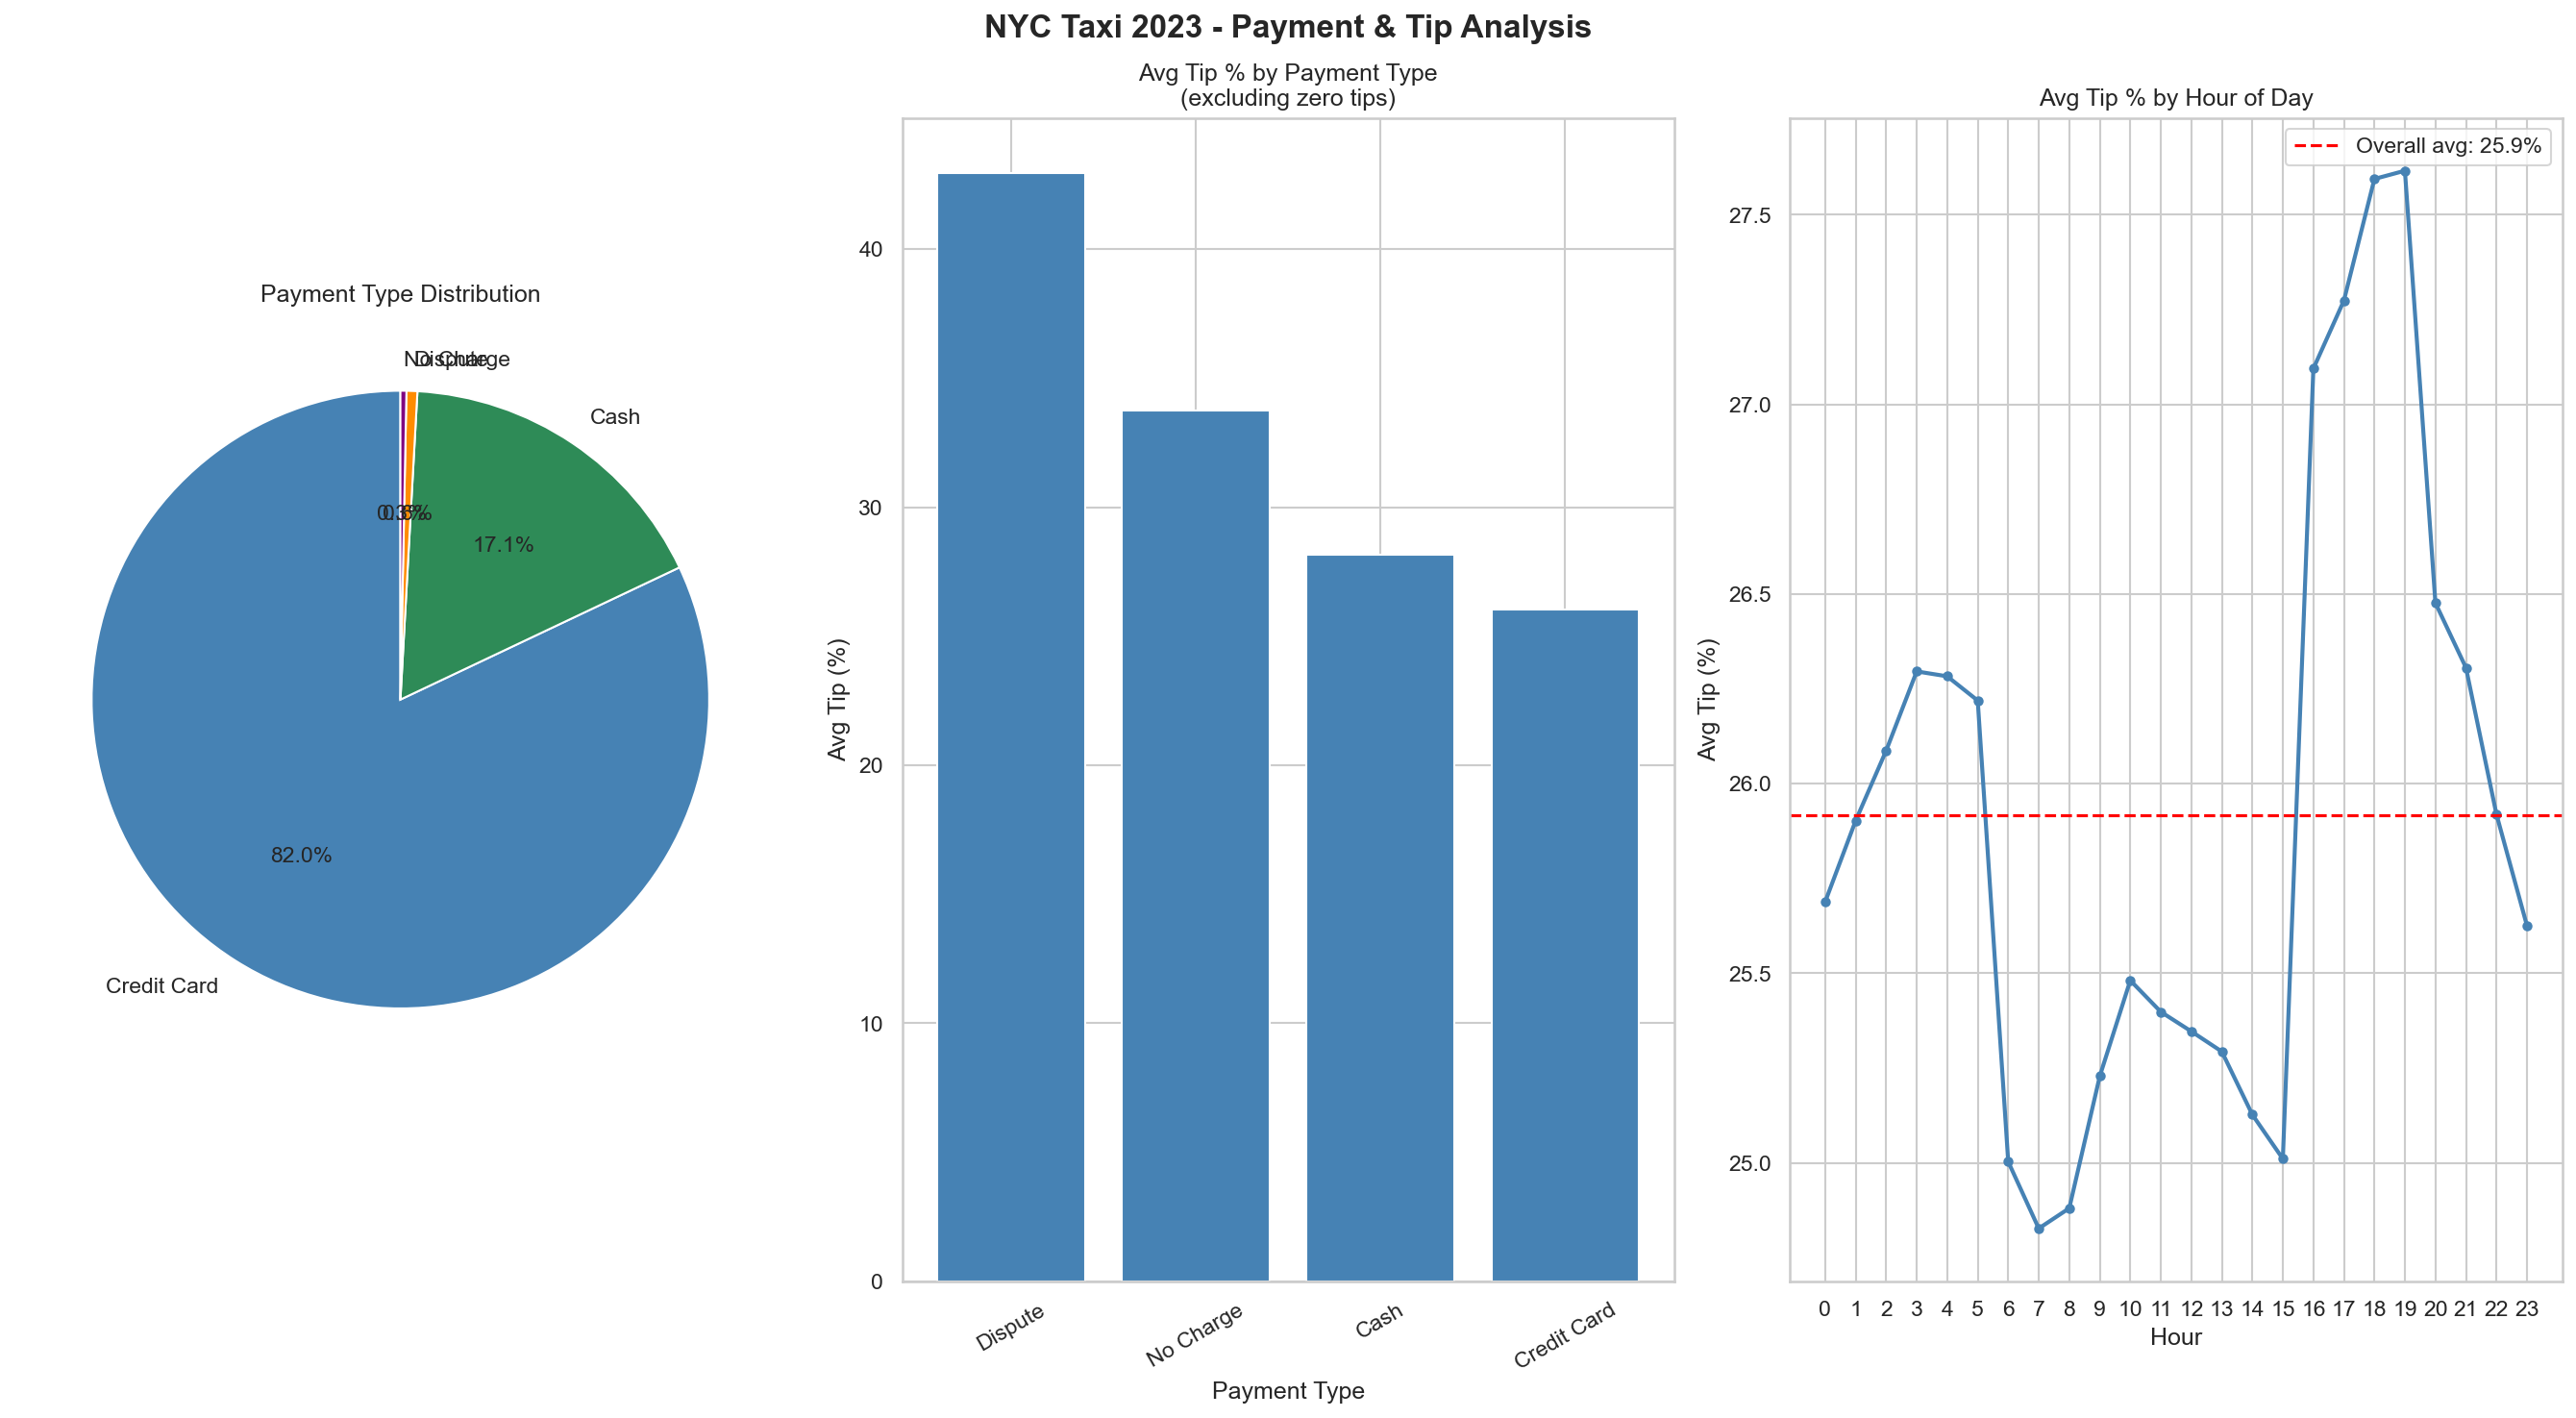

Payment & tip plots saved


In [11]:
fig, axes = plt.subplots(1,3, figsize=(18,10))
fig.suptitle('NYC Taxi 2023 - Payment & Tip Analysis', fontsize = 16, fontweight = 'bold')

# Payment type distribution
payment = df['payment_type_label'].value_counts()
colors_pie = ['steelblue','seagreen','darkorange','purple','salmon']
axes[0].pie(payment.values, labels = payment.index, autopct = '%1.1f%%',
            colors = colors_pie, startangle = 90)
axes[0].set_title('Payment Type Distribution')

# Avg tip % by payment type
tip_by_payment = df[df['tip_pct']>0].groupby('payment_type_label')['tip_pct'].mean().sort_values(ascending=False)
axes[1].bar(tip_by_payment.index, tip_by_payment.values, color = 'steelblue', edgecolor='white')
axes[1].set_title('Avg Tip % by Payment Type\n(excluding zero tips)')
axes[1].set_xlabel('Payment Type')
axes[1].set_ylabel('Avg Tip (%)')
axes[1].tick_params(axis='x', rotation= 30)

# Tip % by hour
tip_by_hour = df[df['tip_pct']>0].groupby('pickup_hour')['tip_pct'].mean()
axes[2].plot(tip_by_hour.index, tip_by_hour.values, color = 'steelblue',linewidth = 2, marker = 'o', markersize=4)
axes[2].axhline(tip_by_hour.mean(), color = 'red',linestyle = '--',label=f"Overall avg: {tip_by_hour.mean():.1f}%")
axes[2].set_title('Avg Tip % by Hour of Day')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Avg Tip (%)')
axes[2].set_xticks(range(0,24))
axes[2].legend()

plt.tight_layout()
plt.savefig('../outputs/nb2_payment_tip_analysis.png', dpi=150, bbox_inches='tight')
plt.show()
print("Payment & tip plots saved")

### Correlation Heatmap:

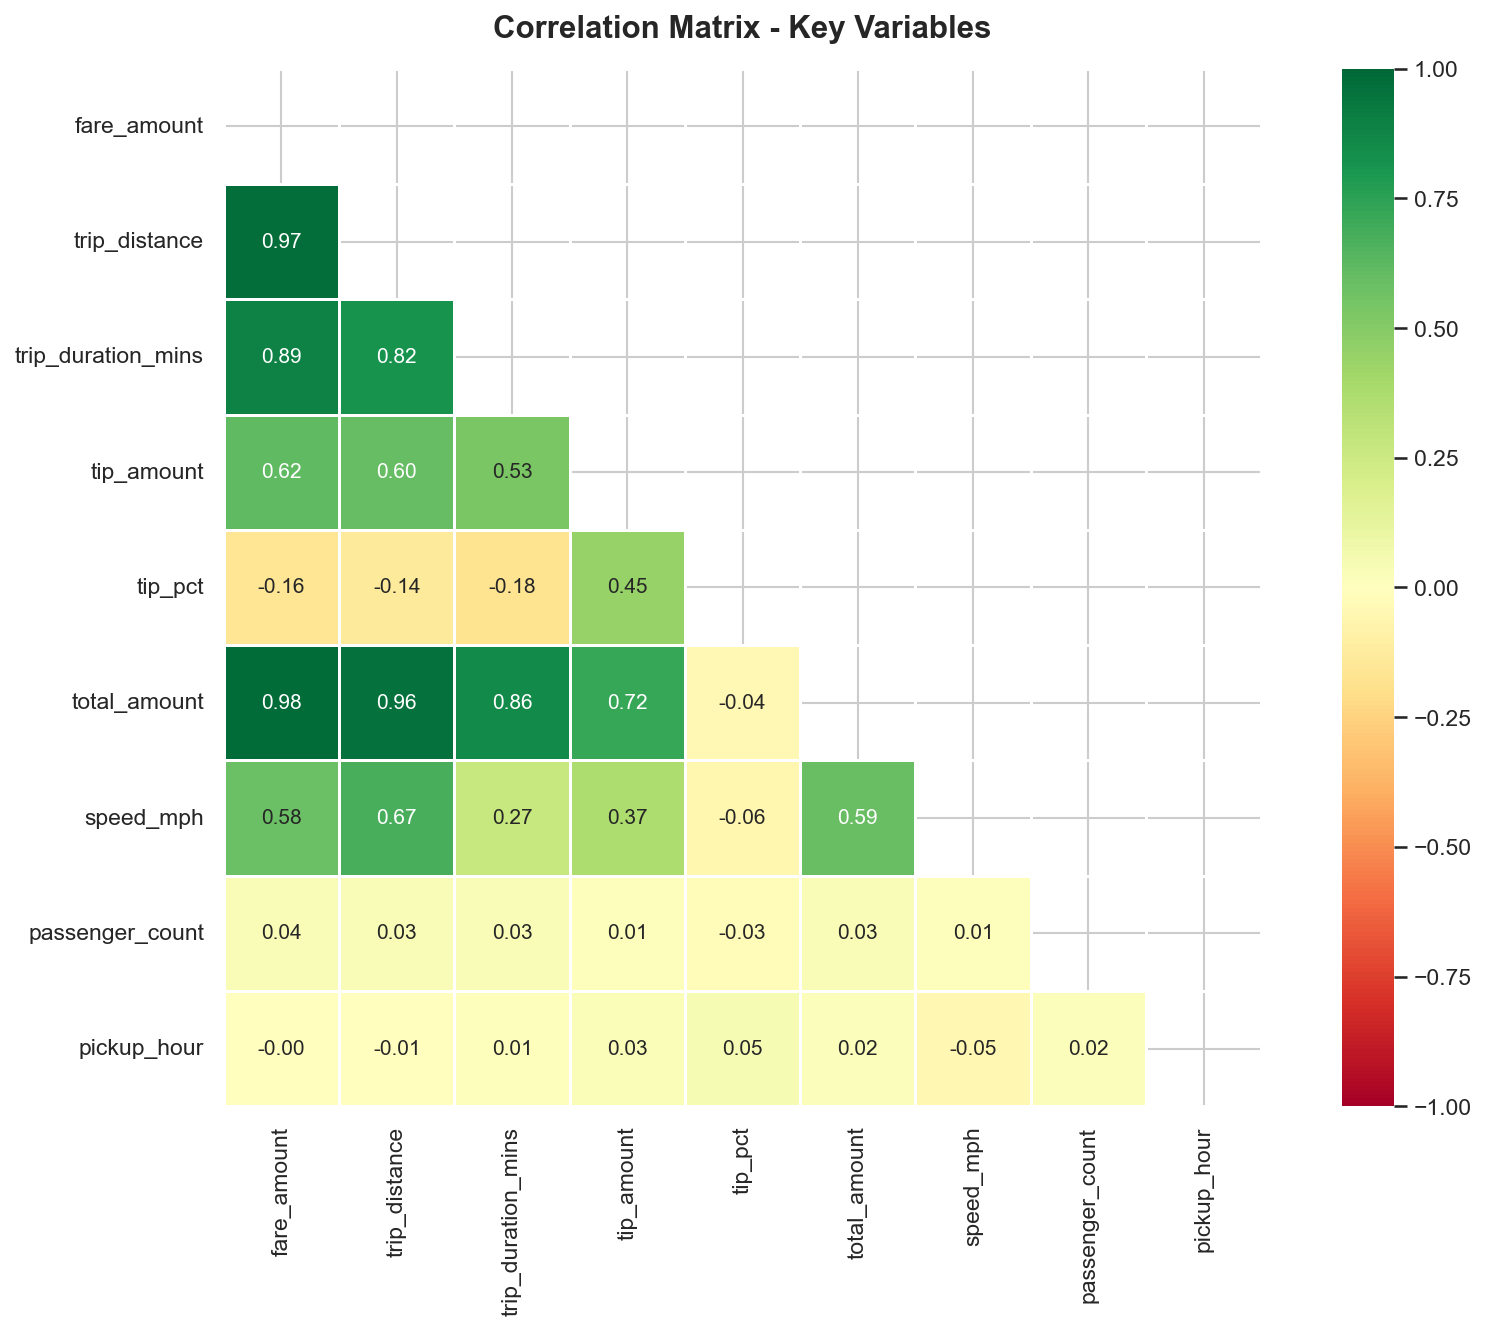

=== KEY CORRELATIONS WITH FARE AMOUNT ===
fare_amount           1.00
total_amount          0.98
trip_distance         0.97
trip_duration_mins    0.89
tip_amount            0.61
speed_mph             0.58
passenger_count       0.04
pickup_hour          -0.00
tip_pct              -0.16
Name: fare_amount, dtype: float64


In [15]:
corr_cols = ['fare_amount','trip_distance','trip_duration_mins','tip_amount','tip_pct',
                'total_amount','speed_mph','passenger_count','pickup_hour']

corr_matrix = df[corr_cols].corr()

# Mask upper triangle AND diagonal
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=0)

fig, ax = plt.subplots(figsize= (12,9))

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt = '.2f',cmap='RdYlGn', center=0,vmin=-1,vmax=1,
                linewidths=0.5, ax=ax, annot_kws={'size':10}, square=True)
ax.set_title('Correlation Matrix - Key Variables', fontsize=15, fontweight='bold',pad=15)
plt.tight_layout()
plt.savefig('../outputs/nb2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print("=== KEY CORRELATIONS WITH FARE AMOUNT ===")
print(corr_matrix['fare_amount'].sort_values(ascending=False).round(3))

## NB2 Key Findings — EDA Summary

### Distributions
- Fare amount is **right-skewed** — most trips are $5-20, long tail of expensive trips
- Trip distance median (~1.8 mi) << mean (~3 mi) — same right skew
- Speed peaks at low values — NYC traffic causes most trips to average 10-15 mph

### Time Patterns
- **Peak hours:** 6-9am and 3-7pm — classic commute windows
- **Overnight (1-5am):** Lowest volume but highest average fares — longer airport/bar trips
- **Friday is busiest day** — highest trip volume
- **Saturday has highest avg fare** — longer leisure trips

### Payment & Tips
- **Credit card dominates** — ~65-70% of all trips
- **Cash tips = 0%** — cash tips not recorded in system
- **Late night tips are highest** — 1-3am tippers are more generous

### Correlations
- `trip_distance` → `fare_amount`: **strongest predictor** (expected)
- `trip_duration_mins` → `fare_amount`: **second strongest**
- `passenger_count` → `fare_amount`: **near zero** — doesn't affect fare
- `pickup_hour` → `tip_pct`: **slight negative** — morning tippers slightly less generous

### Next Step → NB3: Hypothesis Testing & A/B Testing